In [1]:
%load_ext autoreload
%autoreload 2  # Automatically reload all modules before executing code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from process_scores import process_scores
from sklearn.linear_model import Lasso
import itertools

In [2]:
def add_binary_ones_count(df):
    # Create a new column that counts the number of 1s in the binary representation of the index
    df['binary_ones_count'] = df.index.map(lambda x: bin(x).count('1'))
    return df

In [24]:
def create_violin_plots(df, bin_column, data_column,struct_dict):
    """
    Create violin plots for non-NaN values in a data column, binned by an integer column.
    Shows the number of entries in each bin on the plot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    bin_column : str
        The name of the integer column to bin by.
    data_column : str
        The name of the data column to plot.
    """
    # Filter out NaN values from the data column
    filtered_df = df.dropna(subset=[data_column])
    
    if filtered_df.empty:
        print(f"No non-NaN values found in column '{data_column}'.")
        return
    
    # Get unique bin values and sort them
    bins = sorted(filtered_df[bin_column].unique())
    
    if len(bins) == 0:
        print(f"No valid bin values found in column '{bin_column}'.")
        return
    
    # Create a figure with appropriate size
    plt.figure(figsize=(max(10, len(bins) * 1.5), 8))
    
    # Create the violin plot
    ax = sns.violinplot(x=bin_column, y=data_column, data=filtered_df, inner="quartile")
    
    # Set title and labels
    #ax.set_title(f'Violin plot of {data_column} binned by {bin_column}')
    ax.set_xlabel(bin_column)
    ax.set_ylabel(struct_dict[data_column])
    
    # Calculate count for each bin and add as text on the plot
    bin_counts = filtered_df[bin_column].value_counts().sort_index()
    
    # Add count annotations above each violin
    for i, (bin_val, count) in enumerate(bin_counts.items()):
        ax.text(i, ax.get_ylim()[1] * 0.98, f"n={count}", 
                horizontalalignment='center', size='medium', 
                weight='semibold', color='black')
    
    # Improve x-axis labels if there are many bins
    if len(bins) > 10:
        plt.xticks(rotation=45)
    
    #plt.tight_layout()
    plt.show()
    
    # Return some statistics for each bin
    stats = filtered_df.groupby(bin_column)[data_column].agg(['count', 'mean', 'std', 'min', 'max'])
    return stats

In [4]:
scores_dir = 'combinatoric_results/scores'
avg_df, std_df = process_scores(scores_dir)
avg_df.head()

Processing score files: 100%|███████████| 48757/48757 [00:35<00:00, 1371.37it/s]


,1pga,2fs1,2jws,2jwu,2kdl,2kdm
0,-47.0010,7.678734e+07,129.3396,NaN,NaN,NaN
1,-46.7439,7.678734e+07,103.0157,117.1535,119.4554,51.7398
2,-47.7890,7.682949e+07,129.5135,108.4535,121.6482,50.1157
3,-47.7910,7.682949e+07,101.1203,99.4766,111.2759,50.6245
4,-47.9080,7.686733e+07,153.3384,119.8221,122.9996,37.3283


In [ ]:
for i in range(1,8192):
    for

In [5]:
# Read and process score file
n = 7000
pdb_id = '2kdm'
file = '/Users/christopher/Desktop/bb-scripts/combinatoric_results/scores/7000_2kdm_score.sc'
df = pd.read_csv(file, delim_whitespace=True, skiprows=1)
total_scores = df['total_score']

# Update dataframes
avg_df.loc[n, pdb_id] = total_scores.mean()
std_df.loc[n, pdb_id] = total_scores.std()

In [6]:
total_scores.mean()

88.6421

In [7]:
avg_df.loc[5001]

1pga   -4.918190e+01
2fs1    7.702811e+07
2jws    1.742654e+02
2jwu    1.155054e+02
2kdl    1.521700e+02
2kdm    8.650940e+01
Name: 5001, dtype: float64

In [8]:
for column in avg_df.columns:
        nan_count = avg_df[column].isna().sum()
        print(f"Column '{column}': {nan_count} NaN values")

Column '1pga': 0 NaN values
Column '2fs1': 9 NaN values
Column '2jws': 90 NaN values
Column '2jwu': 97 NaN values
Column '2kdl': 99 NaN values
Column '2kdm': 100 NaN values


In [9]:
avg_df = add_binary_ones_count(avg_df)

avg_df.head()

,1pga,2fs1,2jws,2jwu,2kdl,2kdm,binary_ones_count
0,-47.0010,7.678734e+07,129.3396,NaN,NaN,NaN,0
1,-46.7439,7.678734e+07,103.0157,117.1535,119.4554,51.7398,1
2,-47.7890,7.682949e+07,129.5135,108.4535,121.6482,50.1157,1
3,-47.7910,7.682949e+07,101.1203,99.4766,111.2759,50.6245,2
4,-47.9080,7.686733e+07,153.3384,119.8221,122.9996,37.3283,1


In [10]:
format(1, '013b')

'0000000000001'

In [11]:
avg_df['binary'] = avg_df.index.map(lambda x: format(x, '013b'))
avg_df.head()

,1pga,2fs1,2jws,2jwu,2kdl,2kdm,binary_ones_count,binary
0,-47.0010,7.678734e+07,129.3396,NaN,NaN,NaN,0,0000000000000
1,-46.7439,7.678734e+07,103.0157,117.1535,119.4554,51.7398,1,0000000000001
2,-47.7890,7.682949e+07,129.5135,108.4535,121.6482,50.1157,1,0000000000010
3,-47.7910,7.682949e+07,101.1203,99.4766,111.2759,50.6245,2,0000000000011
4,-47.9080,7.686733e+07,153.3384,119.8221,122.9996,37.3283,1,0000000000100


In [12]:
def create_epistatic_features(sequences):
    n_samples, n_bits = sequences.shape
    
    # First-order features (individual bits)
    X1 = sequences.copy()
    
    # Second-order features (pairwise interactions)
    pairs = list(itertools.combinations(range(n_bits), 2))
    X2 = np.zeros((n_samples, len(pairs)))
    
    for i, (bit1, bit2) in enumerate(pairs):
        X2[:, i] = sequences[:, bit1] * sequences[:, bit2]
    
    # Combine features
    X = np.hstack((X1, X2))
    
    # Feature names for interpretation
    feature_names = [f"bit_{i}" for i in range(n_bits)]
    feature_names += [f"bit_{i}×bit_{j}" for i, j in pairs]
    
    return X, feature_names

In [13]:
create_epistatic_features(avg_df['binary'])

ValueError: not enough values to unpack (expected 2, got 1)

In [43]:
for column in avg_df.columns:
    print(column)

1pga
2fs1
2jws
2jwu
2kdl
2kdm
binary_ones_count


In [14]:
struct_dict = {'2kdl':'GA95','2kdm':'GB95','2jws':'GA88','2jwu':'GB88', '1pga':'GBWT','2fs1':'GAWT'}

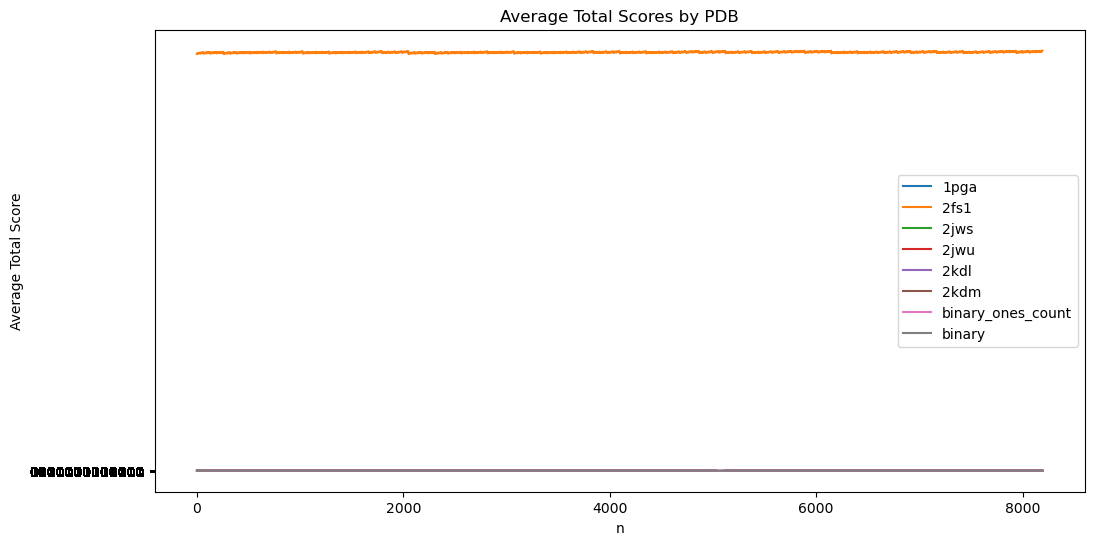

In [15]:
# Second cell
plt.figure(figsize=(12, 6))
for pdb in avg_df.columns:
    plt.plot(avg_df.index, avg_df[pdb], label=pdb)
plt.xlabel('n')
plt.ylabel('Average Total Score')
plt.title('Average Total Scores by PDB')
plt.legend()
plt.show()

In [34]:
i = 5
struct_dict[avg_df.columns[i]]

'GB95'

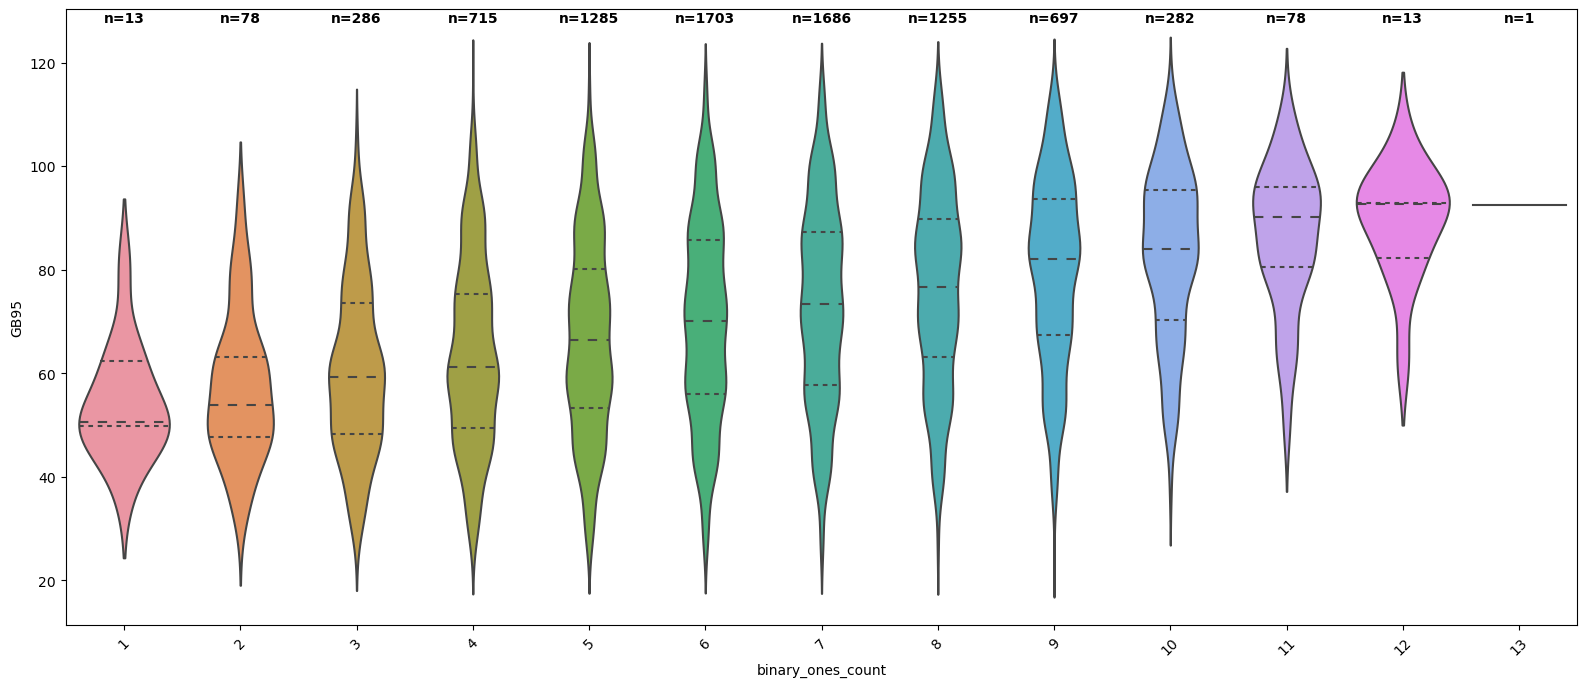

,count,mean,std,min,max
binary_ones_count,,,,,
1,13,53.955246,10.848926,37.3283,80.6707
2,78,57.237631,14.103770,30.8461,92.8633
3,286,60.457271,16.321548,28.5584,104.3311
4,715,63.588689,17.852934,26.9563,114.7990
5,1285,66.765281,18.841870,26.5043,114.8524
6,1703,69.944063,19.298427,26.2613,114.9258
7,1686,73.098831,19.353135,26.2243,114.9685
8,1255,76.349246,18.915252,26.3812,114.9494
9,697,79.648506,17.953035,26.4426,114.8356


In [35]:
create_violin_plots(avg_df, "binary_ones_count", avg_df.columns[i],struct_dict)


(array([143., 225., 372., 408., 359., 302., 166.,  71.,   2.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  60., 242., 362.,
        501., 709., 584., 416., 118.,  74.]),
 array([-76.047   , -75.455918, -74.864836, -74.273754, -73.682672,
        -73.09159 , -72.500508, -71.909426, -71.318344, -70.727262,
        -70.13618 , -69.545098, -68.954016, -68.362934, -67.771852,
        -67.18077 , -66.589688, -65.998606, -65.407524, -64.816442,
        -64.22536 , -63.634278, -63.043196, -62.452114, -61.861032,
        -61.26995 , -60.678868, -60.087786, -59.496704, -58.905622,
        -58.31454 , -57.723458, -57.132376, -56.541294, -55.950212,
        -55.35913 , -54.768048, -54.176966, -53.585884, -52.994802,
        -52.40372 , -51.812638, -51.221556, -50.630474, -50.039392,
        -49.44831 , -48.857228, -48.266146, -4

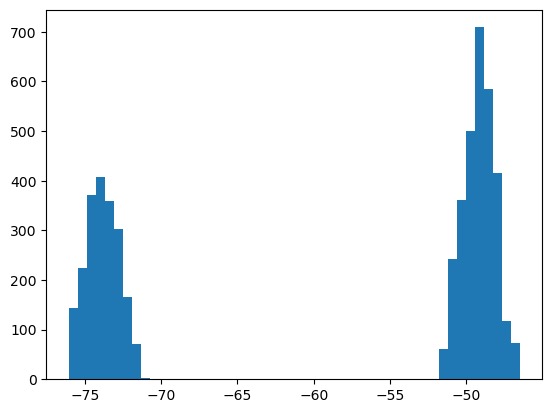

In [108]:
plt.hist(avg_df['1pga'],bins=50)

In [ ]:
nan_count = avg_df['column_name'].isna().sum()